# **Building a Flight Price Prediction Model**

---

### Project Type - MLOps - Regression

### Contribution - Individual - Aiman Sahay

---

## **PROJECT SUMMARY**

This project focuses on building an end-to-end **flight price prediction system** using regression techniques, with an emphasis on both **machine learning modeling** and **MLOps practices**. The objective was to accurately predict flight ticket prices based on various features such as route, travel time, distance, booking agency, flight type, and temporal attributes.

The dataset used for this project consisted of flight-related information, supplemented by additional datasets for hotels and users. However, the primary modeling was performed on the flight dataset. Initial data exploration confirmed that the dataset was clean, with no missing or duplicate values. This allowed for a smoother preprocessing phase and ensured reliability in downstream modeling.

Feature engineering played a key role in improving model performance. Date-related features such as weekday, week number, month, and year were extracted to capture temporal patterns in pricing. Additionally, a new feature **flight speed** was derived from distance and travel time to capture operational efficiency, which can influence pricing. Categorical variables such as origin, destination, flight type, and agency were transformed using one-hot encoding.

Extensive exploratory data analysis (EDA) revealed important insights. For instance, flight prices showed a positive correlation with both travel time and distance. Pricing patterns also varied significantly across flight classes and booking agencies, with first-class tickets and certain agencies commanding higher prices. These insights helped validate feature relevance before model training.

Multiple regression models were implemented and compared, including **Linear Regression, Lasso, Ridge, Decision Tree, Random Forest, and XGBoost**. Each model was evaluated using key performance metrics such as **Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared**. Hyperparameter tuning was performed using GridSearchCV and RandomizedSearchCV to optimize model performance.

While the Decision Tree model achieved strong performance on training data, it showed signs of overfitting. In contrast, the **Random Forest Regressor** provided a better balance between bias and variance by aggregating predictions from multiple trees. After hyperparameter tuning, the Random Forest model achieved an **R-squared of approximately 0.86**, along with a low RMSE, making it the most robust and reliable model for this use case.

From an **MLOps** perspective, the project extends beyond model building to include a complete deployment pipeline. 
- A **REST API** was developed using Flask to serve the regression model and enable real-time flight price predictions.
- The application was **containerized using Docker**, ensuring portability and consistent deployment across environments.
- For scalability, the solution was deployed using **Kubernetes**, allowing efficient handling of varying workloads.
- **Apache Airflow** was used to design and manage automated workflows through DAGs, enabling streamlined data processing and model pipeline orchestration.
- **MLflow** was integrated for experiment tracking and model versioning, ensuring a structured and reproducible approach to managing multiple model iterations and deployments.

This project demonstrates a complete machine learning lifecycle - from data preprocessing and feature engineering to model selection, evaluation, and deployment. It highlights the importance of combining strong analytical modeling with production-ready practices to build scalable and practical machine learning solutions.

---

## **GITHUB LINK**

https://github.com/AimanSahay/MLOps-Project

---
## **PROJECT OBJECTIVE**

- **Regression Model Development:**
Build a regression model to predict the price of a flight using the flights.csv dataset. Focus on feature selection, model training, and validation to ensure accuracy and reliability.

- **REST API for Regression Model:**
Develop a REST API using Flask to serve the flight price prediction model, enabling real-time price predictions.

- **Containerization:**
Package and deploy the flight price prediction model using Docker, ensuring portability and ease of deployment.

- **Kubernetes for Scalability:**
Deploy the model using Kubernetes to manage scalability and handle varying loads efficiently.

- **Automated Workflows with Apache Airflow:**
Design and implement automated workflows for managing the travel data, specifically for the regression models. Develop Directed Acyclic Graphs (DAGs) to orchestrate complex workflows in an efficient and manageable way.

- **Model Tracking with MLFlow:**
Utilize MLFlow for tracking and managing different versions of the travel price prediction model, ensuring a systematic approach to model iteration and deployment.

---
# ***Let's Begin !***



#### **Importing Necessary Libraries**

In [2]:
# !pip install flask
# !pip install flask_ngrok pyngrok sentence-transformers
# !pip install blinker
# !pip install statsmodels

In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

import pickle

---
## **Data Loading**

In [6]:
flight_df=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/flights.csv",on_bad_lines='skip')
hotel_df=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/hotels.csv",on_bad_lines='skip')
user_df=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/users.csv",on_bad_lines='skip')

In [7]:
flight_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [10]:
hotel_df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [11]:
user_df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


---
## **Data Mining and Exploration**

#### **Dataset Shape**

In [8]:
# Shape of the dataset
df_list = [flight_df, hotel_df, user_df]
df_name_list = ['flight_df', 'hotel_df', 'user_df']

for df_name, df in zip(df_name_list, df_list):
    print(f'Total no. of rows and columns in {df_name}: {df.shape}')

Total no. of rows and columns in flight_df: (271888, 10)
Total no. of rows and columns in hotel_df: (40552, 8)
Total no. of rows and columns in user_df: (1340, 5)


#### **Dataset Info (Non-nulls + Data Type)**

In [9]:
# Dataset Info
for df_name, df in zip(df_name_list, df_list):
    print(f'{df_name} Dataset Info:-\n')
    print(df.info())
    print()

flight_df Dataset Info:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB
None

hotel_df Dataset Info:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  i

#### **Summary Statistics for Numerical Columns**

In [12]:
# Summary statistics of numeric columns

for df_name, df in zip(df_name_list, df_list):
    print(f'{df_name} Dataset Summary Statistics:-\n')
    print(df.describe())
    print()

flight_df Dataset Summary Statistics:-

          travelCode       userCode         price           time  \
count  271888.000000  271888.000000  271888.00000  271888.000000   
mean    67971.500000     667.505495     957.37503       1.421147   
std     39243.724665     389.523127     362.31189       0.542541   
min         0.000000       0.000000     301.51000       0.440000   
25%     33985.750000     326.000000     672.66000       1.040000   
50%     67971.500000     659.000000     904.00000       1.460000   
75%    101957.250000    1011.000000    1222.24000       1.760000   
max    135943.000000    1339.000000    1754.17000       2.440000   

            distance  
count  271888.000000  
mean      546.955535  
std       208.851288  
min       168.220000  
25%       401.660000  
50%       562.140000  
75%       676.530000  
max       937.770000  

hotel_df Dataset Summary Statistics:-

          travelCode      userCode          days         price         total
count   40552.000000  4

#### **Summary Statistics for Categorical Columns**

In [13]:
# Summary statistics of categorical columns
for i, df in zip(df_name_list, df_list):
    print(f'{i} Dataset Summary Statistics:-\n')
    print(df.describe(include='object'))
    print()

flight_df Dataset Summary Statistics:-

                      from                  to  flightType   agency  \
count               271888              271888      271888   271888   
unique                   9                   9           3        3   
top     Florianopolis (SC)  Florianopolis (SC)  firstClass  Rainbow   
freq                 57317               57317      116418   116752   

              date  
count       271888  
unique         999  
top     09/26/2019  
freq          1335  

hotel_df Dataset Summary Statistics:-

           name          place        date
count     40552          40552       40552
unique        9              9         199
top     Hotel K  Salvador (BH)  10/03/2019
freq       5094           5094         404

user_df Dataset Summary Statistics:-

       company               name gender
count     1340               1340   1340
unique       5               1338      3
top       4You  Charlotte Johnson   male
freq       453                  2    452


#### **Missing Values**

In [15]:
# Check for Missing Values
for i, df in zip(df_name_list, df_list):
    print(f'Total no. of missing values in {i}:\n{df.isnull().sum()}\n')

Total no. of missing values in flight_df:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Total no. of missing values in hotel_df:
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

Total no. of missing values in user_df:
code       0
company    0
name       0
gender     0
age        0
dtype: int64



***There are no missing values in any of the datasets.***

#### **Duplicate Values**

In [16]:
# Check for Duplicate rows
for i, df in zip(df_name_list, df_list):
    print(f'Total no. of duplicate rows in {i}: {df.duplicated().sum()}')


Total no. of duplicate rows in flight_df: 0
Total no. of duplicate rows in hotel_df: 0
Total no. of duplicate rows in user_df: 0


***There are no duplicate values in any of the datasets.***

---
## **Data Preprocessing**

In [17]:
# Converting date column data type into datetime
flight_df['date'] = pd.to_datetime(flight_df['date'])

# Extracting Weekday, Month, WeekNumber, Year, Day from date column
flight_df['week_day'] = flight_df['date'].dt.weekday
flight_df['month'] = flight_df['date'].dt.month
flight_df['week_no'] = flight_df['date'].dt.isocalendar().week
flight_df['year'] = flight_df['date'].dt.year
flight_df['day'] = flight_df['date'].dt.day

In [18]:
flight_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,week_day,month,week_no,year,day
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,3,9,39,2019,26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,0,9,40,2019,30
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,3,10,40,2019,3
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,4,10,40,2019,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,3,10,41,2019,10


##### Filtering the dataframe based on relevant column

In [19]:
flights_filtered= flight_df[['from','to','flightType','agency','time','distance','week_day','week_no','day','month','year','price']]
flights_filtered.head()

,from,to,flightType,agency,time,distance,week_day,week_no,day,month,year,price
0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,1.76,676.53,3,39,26,9,2019,1434.38
1,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,1.76,676.53,0,40,30,9,2019,1292.29
2,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,1.66,637.56,3,40,3,10,2019,1487.52
3,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,1.66,637.56,4,40,4,10,2019,1127.36
4,Aracaju (SE),Salvador (BH),firstClass,CloudFy,2.16,830.86,3,41,10,10,2019,1684.05


In [20]:
flights_filtered.shape

(271888, 12)

---
## **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

#### **Numerical Column Distribution**

Check for skewness in the distribution of numerical Columns

In [21]:
# Filter only numerical columns
numerical_columns = flights_filtered.select_dtypes(include=['number']).columns

# Calculate skewness for numerical columns
skewness = flights_filtered[numerical_columns].skew()

# Print skewness
print(skewness)


time       -0.179825
distance   -0.183944
week_day   -0.441701
week_no    -0.030191
day         0.006463
month      -0.039119
year        0.378661
price       0.313578
dtype: Float64


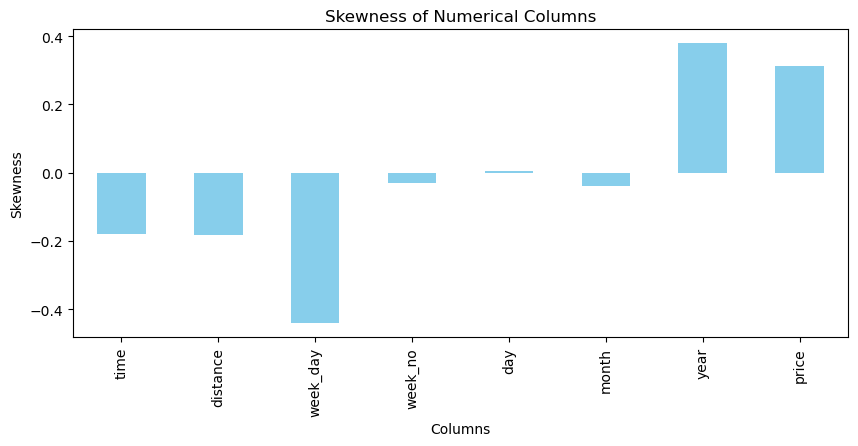

In [23]:
# Select numerical columns only
numerical_columns = flights_filtered.select_dtypes(include=['number']).columns

# Calculate skewness for numerical columns
skewness = flights_filtered[numerical_columns].skew()

# Plot skewness as a bar chart
skewness.plot(kind='bar', figsize=(10, 4), color='skyblue', title="Skewness of Numerical Columns")
plt.xlabel('Columns')
plt.ylabel('Skewness')
plt.show()



The **skewness value** helps us understand and check whether and which variables are normally distributed. The skewness value is generally interpreted as follows:

- The variables with skewness > 1 price are highly positively skewed: None
- The variables with skewness < -1 are highly negatively skewed: None
- The variables with 0.5 < skewness < 1 are moderately positively skewed: None
- The variables with -0.5 < skewness < -1 are moderately negatively skewed: None
- The variables with -0.5 < skewness < 0.5 are symmetric: All variables' skewness lies between -0.5 and +0.5.

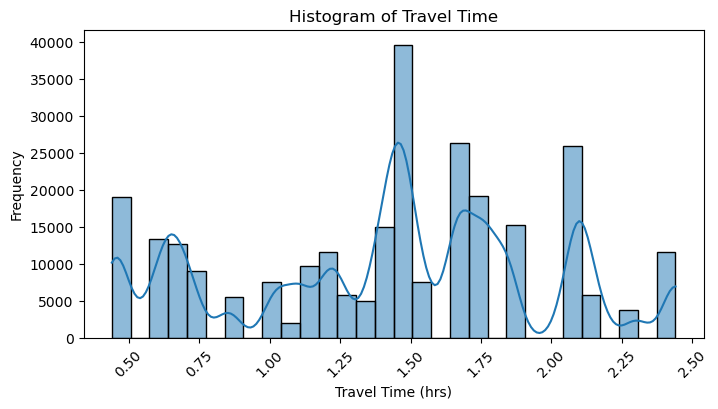

In [24]:
# Histogram with KDE of the 'time' column

plt.figure(figsize=(8, 4))
sns.histplot(flights_filtered['time'], bins=30, kde=True)
plt.title('Histogram of Travel Time')
plt.xlabel('Travel Time (hrs)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Observation:** Highest occurrence of travel time is 1.5 hours, followed by 1.75 and 2 hour flights.

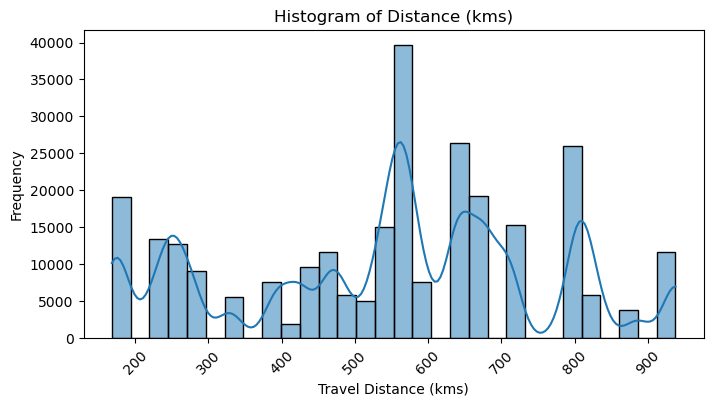

In [25]:
# Distribution of Distance 

plt.figure(figsize=(8, 4))
sns.histplot(flights_filtered['distance'], bins=30, kde=True)
plt.title('Histogram of Distance (kms)')
plt.xlabel('Travel Distance (kms)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Observation:** The distance travelled most frequently is ~550 kms and the range is generally of 550 - 800 kms.

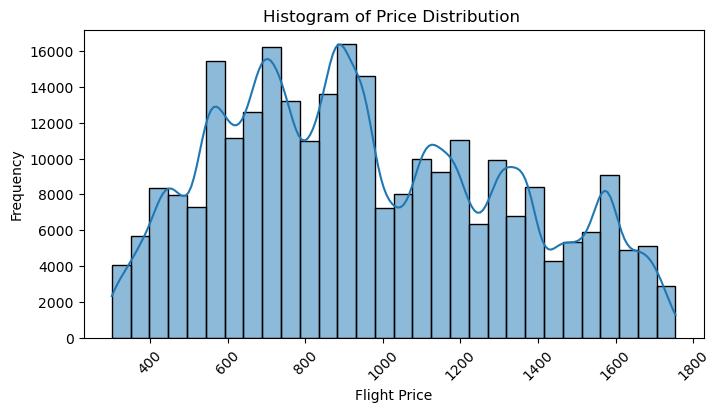

In [26]:
# Flight Price Distribution

plt.figure(figsize=(8, 4))
sns.histplot(flights_filtered['price'], bins=30, kde=True)
plt.title('Histogram of Price Distribution ')
plt.xlabel('Flight Price')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Observation:**

The prices are distributed across a wide range, however, it can be observed that majority of bookings / flights have been in the lower range of 300 - 1000 while comparatively fewer bookings are > 1000. This information provides insights on the affordability and income levels of majority of the flyers.

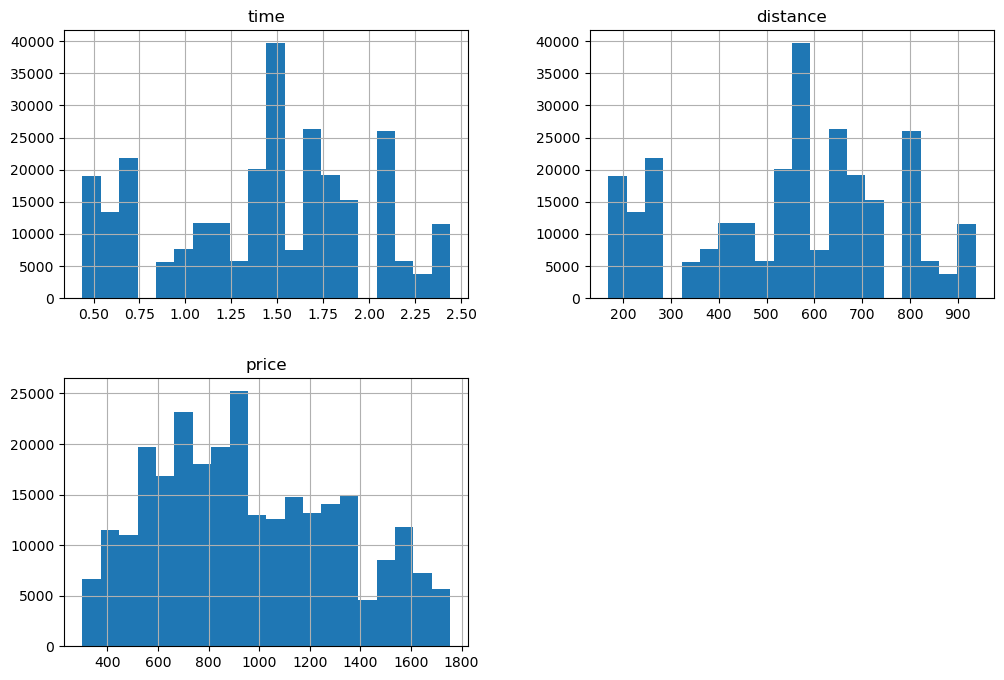

In [27]:
# Histograms of all numeric columns
numeric_cols = flights_filtered.select_dtypes(include=['int64', 'float64']).columns
flights_filtered[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.show()

#### **Outlier detection in Numerical Coulmns using Box-plot**

If the distribution of numerical columns follows normal distribution, then use standard deviation to handle outliers.
Otherwise we will use IQR technique to handle outliers.

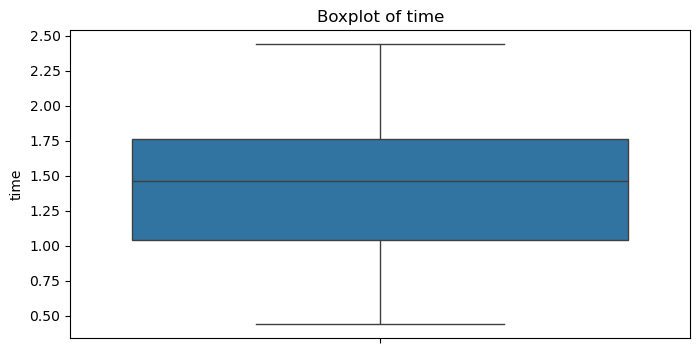

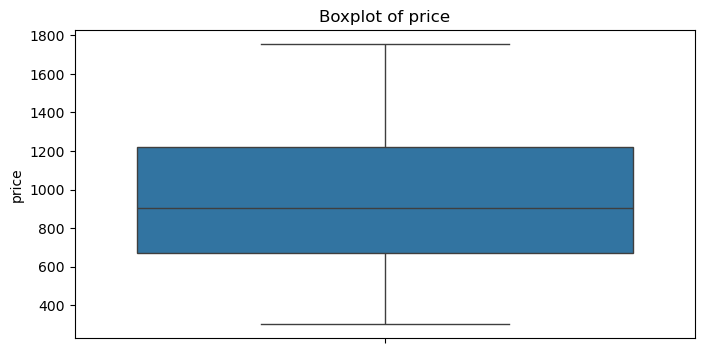

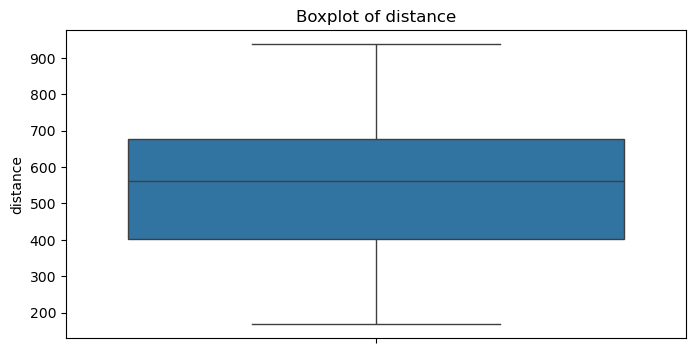

In [28]:
# Function to plot box plots
def plot_boxplot(data, column_name, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data[column_name])
    plt.xticks(rotation=45)
    plt.title(f'Boxplot of {column_name}')
    plt.show()

# Plot box plots for 'time','price','distance' columns
plot_boxplot(flights_filtered, 'time')
plot_boxplot(flights_filtered, 'price')
plot_boxplot(flights_filtered, 'distance')


**Observation:** No significant outliers detected in price, time and distance features.

#### **Distribution of Categorical Columns using Count-plot**

In [31]:
flights_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   from        271888 non-null  object 
 1   to          271888 non-null  object 
 2   flightType  271888 non-null  object 
 3   agency      271888 non-null  object 
 4   time        271888 non-null  float64
 5   distance    271888 non-null  float64
 6   week_day    271888 non-null  int32  
 7   week_no     271888 non-null  UInt32 
 8   day         271888 non-null  int32  
 9   month       271888 non-null  int32  
 10  year        271888 non-null  int32  
 11  price       271888 non-null  float64
dtypes: UInt32(1), float64(3), int32(4), object(4)
memory usage: 20.0+ MB


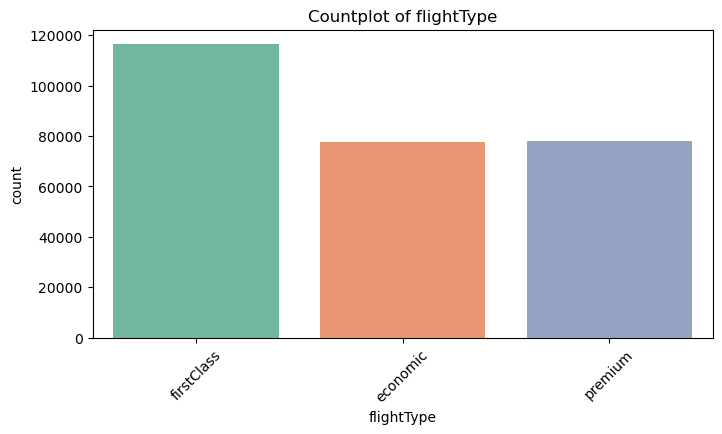

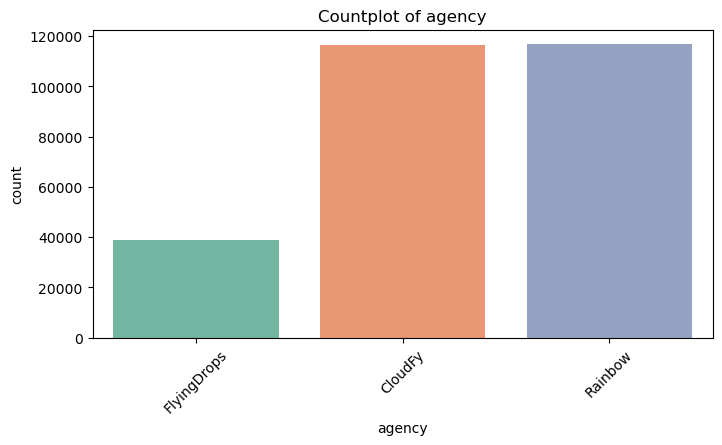

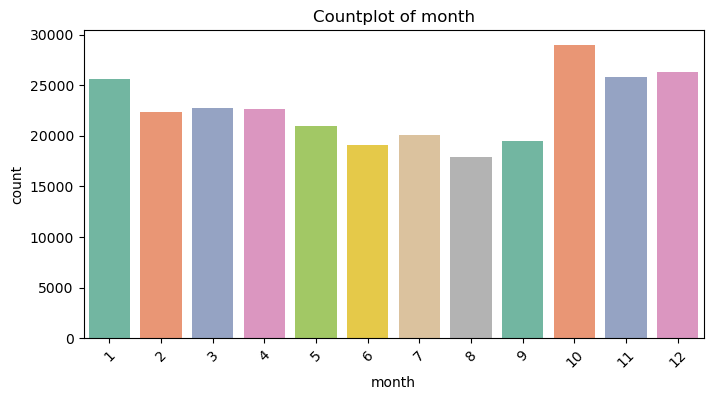

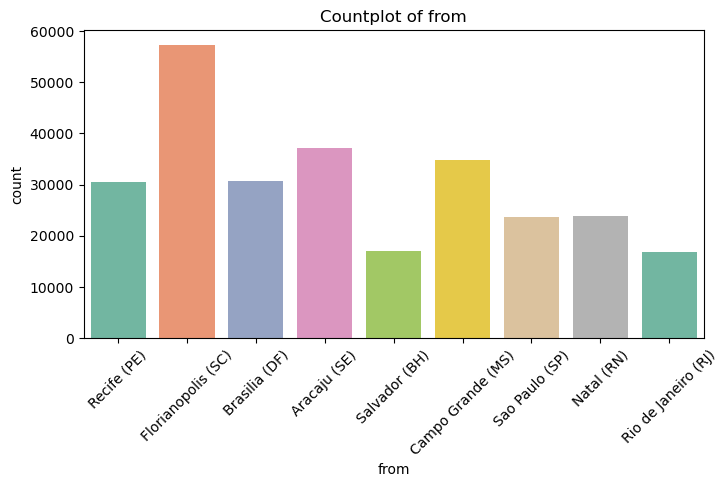

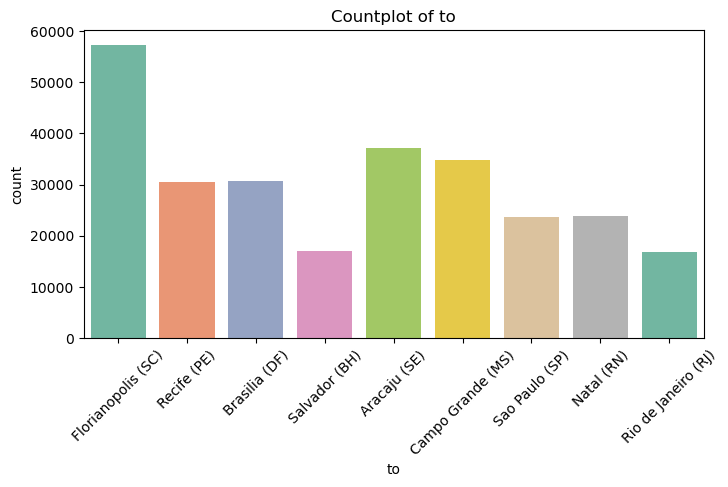

In [30]:
# List of columns to plot countplots for
columns_to_plot = ['flightType', 'agency', 'month', 'from', 'to']
data = [flights_filtered, flights_filtered, flights_filtered, flights_filtered, flights_filtered]  # Corresponding data for each plot

# Define a function to plot countplots
def plot_countplot(data, column_name, palette="Set2", figsize=(8, 4)):
    plt.figure(figsize=figsize)
    sns.countplot(x=column_name, data=data, palette=palette)
    plt.title(f'Countplot of {column_name}')
    plt.xticks(rotation=45)
    plt.show()

# Plot countplots for the specified columns
for col, df in zip(columns_to_plot, data):
    plot_countplot(df, col)


**Observation:**

- Flight type 'firstClass' has the highest bookings while 'economic' and 'premium' are about the same.
- 'CloundFy' and 'Rainbow' agencies have had the largest bookings and 'FlyingDrops' seems to be the last choice.
- Highest number of bookings have been in October and the peak travel period is October - January.
- The most famous 'to' and 'from' destination is 'Florianopolis (SC).

#### **Distribution of Week Days and Year using a pie-chart**

week_day counts:
week_day
3    135944
0     34108
6     34088
4     33880
5     33868
Name: count, dtype: int64


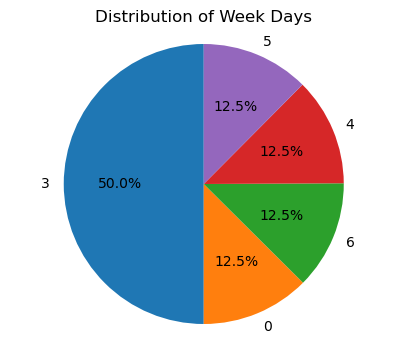

year counts:
year
2020    112571
2021     75363
2022     41761
2019     35826
2023      6367
Name: count, dtype: int64


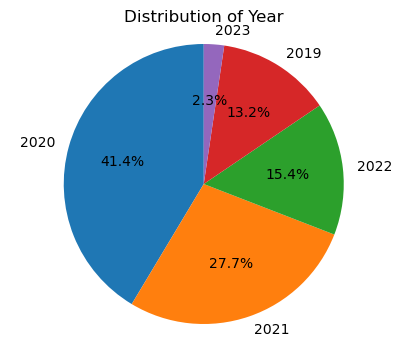

In [31]:
# Define a function to create and display pie charts
def plot_pie_chart(data, column_name, title, figsize=(5, 4)):
    counts = data[column_name].value_counts()
    print(f'{column_name} counts:\n{counts}')
    plt.figure(figsize=figsize)
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(title)
    plt.axis('equal')  # Ensures the pie chart is a circle
    plt.show()

# Plot pie charts for numerical columns with discrete values
plot_pie_chart(flights_filtered, 'week_day', 'Distribution of Week Days')
plot_pie_chart(flights_filtered, 'year', 'Distribution of Year')


**Observation**:

- About 50% of the flights have been on Thursday and the remaining 50% are equally distributed across Monday and Friday to Sunday.
- Surprisingly, highest number of flights have been in the year 2020 (even though it was the COVID year) followed by 2021, while fewer flights have been booked in 2019 and 2022-2023.

### **Bivariate Analysis**

#### **Relationship between independent numerical variables and target variable using Scatter Plot**

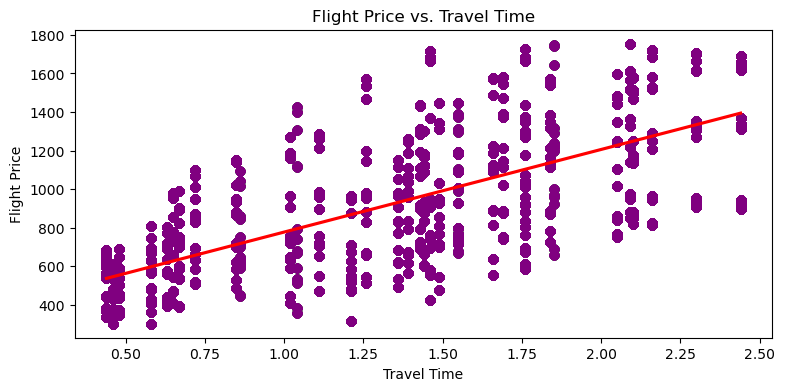

In [38]:
plt.figure(figsize=(9, 4))

sns.regplot(
    data=flights_filtered,
    x='time',
    y='price',
    scatter_kws={'color': 'purple', 'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Flight Price vs. Travel Time')
plt.xlabel('Travel Time')
plt.ylabel('Flight Price')
plt.show()

**Observation:**

A clear upward trend can be observed in the 'travel time vs price' plot indicating that flight prices generally tend to higher for longer duration flights. (positive correlation)

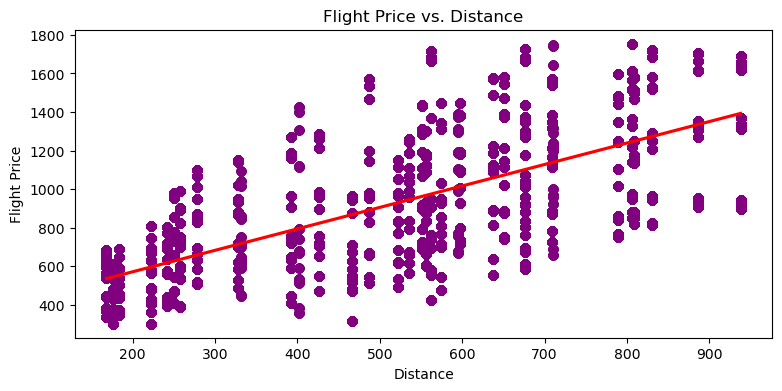

In [40]:
# Price vs. Travel Distance

plt.figure(figsize=(9, 4))

sns.regplot(
    data=flights_filtered,
    x='distance',
    y='price',
    scatter_kws={'color': 'purple', 'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Flight Price vs. Distance')
plt.xlabel('Distance')
plt.ylabel('Flight Price')
plt.show()


**Observation:**

A clear upward trend can be observed in the 'distance vs price' plot indicating that flight prices generally tend to higher for long-distance flights. (positive correlation)

#### **Outliers in Categorical Columns using Box Plots**

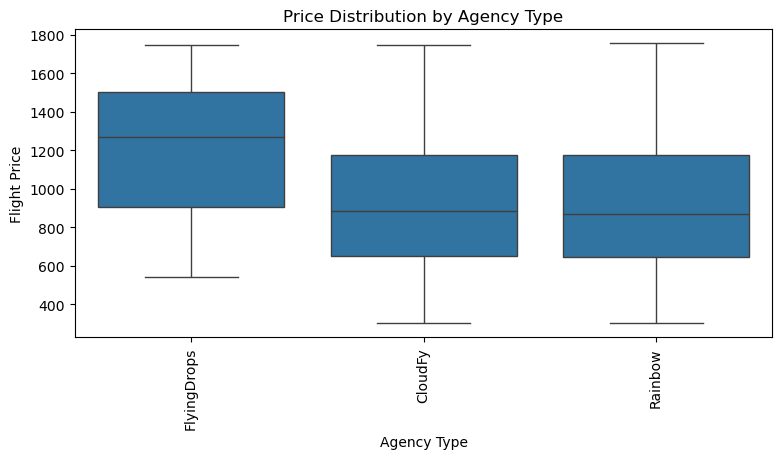

In [41]:
# Distribution of prices per agency type:

plt.figure(figsize=(9, 4))
sns.boxplot(data=flights_filtered, x='agency', y='price')
plt.xticks(rotation=90)
plt.xlabel('Agency Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Agency Type')
plt.show()

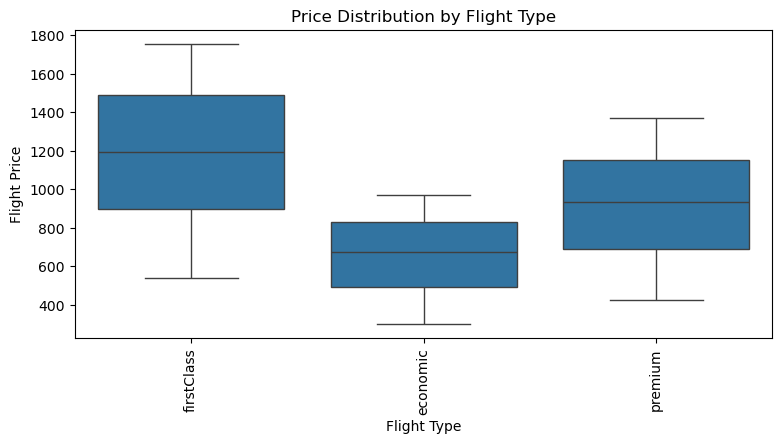

In [42]:
# Distribution of prices per Flight type:

plt.figure(figsize=(9, 4))
sns.boxplot(data=flights_filtered, x='flightType', y='price')
plt.xticks(rotation=90)
plt.xlabel('Flight Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Flight Type')
plt.show()

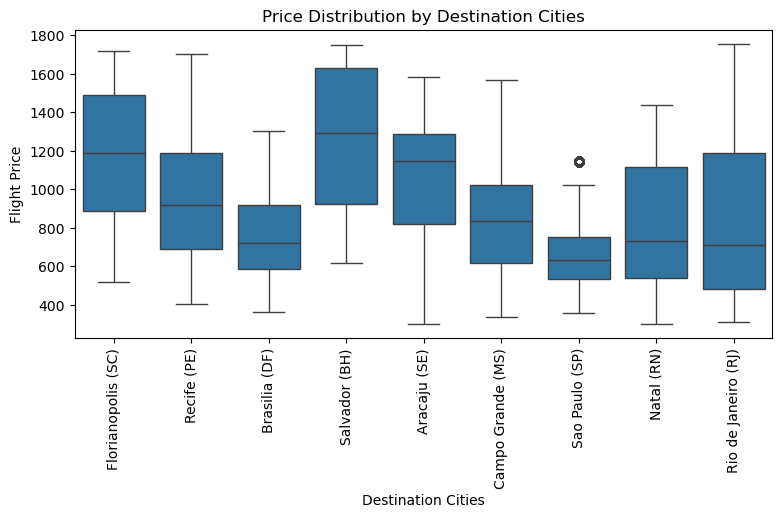

In [43]:
# Distribution of prices per Destination Cities:

plt.figure(figsize=(9, 4))
sns.boxplot(data=flights_filtered, x='to', y='price')
plt.xticks(rotation=90)
plt.xlabel('Destination Cities')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Destination Cities')
plt.show()

**Observation**:

- **Variability**: Varying levels of price variability within different categories. Larger boxes indicate wider range of prices while smaller boxes indicate narrower ranges.

- **Outliers**: No signicant outliers are observed across any of the categories.

#### **Distribution of prices across categorical columns using Bar Plot**

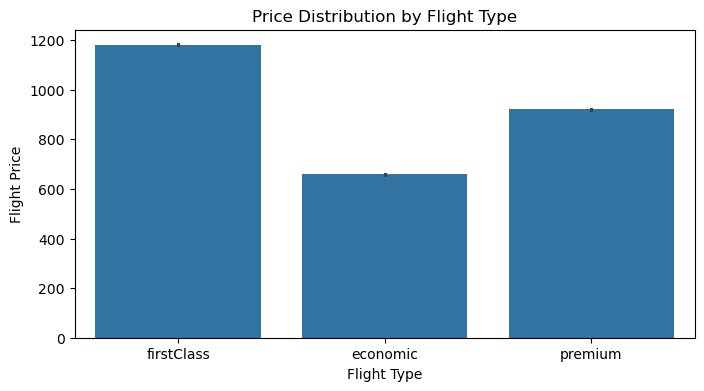

In [44]:
plt.figure(figsize=(8, 4))
sns.barplot(x='flightType',y='price', data=flights_filtered)
plt.xlabel('Flight Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Flight Type')
plt.show()


**Observation:**

The most expensive flight Class Type is FirstClass, followed by Premium Class and Economic Class, as expected.

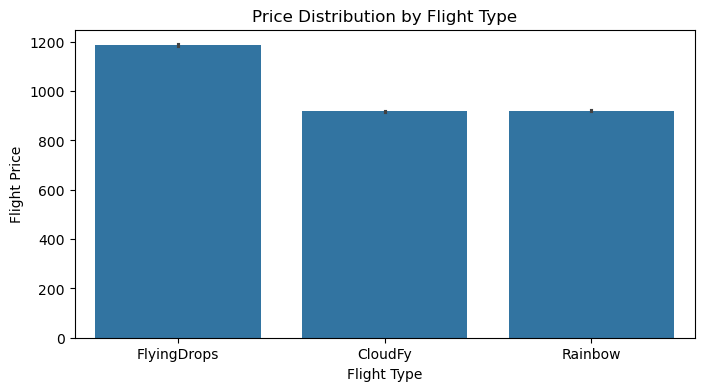

In [45]:
plt.figure(figsize=(8, 4))
sns.barplot(x='agency',y='price', data=flights_filtered)
plt.xlabel('Flight Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Flight Type')
plt.show()


**Observation:**

The most expensive flight tickets agency was Flyingdrops, followed by Rainbow Class and Cloudfy agency. This also explains why FlyingDrops was the least preferred for booking flight tickets (as was seen in a bar plot above that FlyingDrops agency had the lowest number of flight bookings compared to the other two).

### **Multi-Variate Analysis**

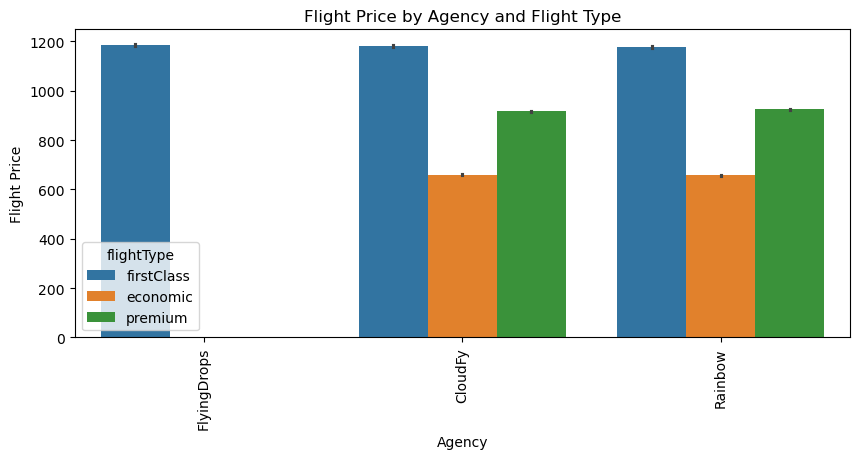

In [48]:
# Explore the relationship between the agency and flight types:

plt.figure(figsize=(10, 4))
sns.barplot(data=flights_filtered, x='agency', y='price', hue='flightType')
plt.xticks(rotation=90)
plt.xlabel('Agency')
plt.ylabel('Flight Price')
plt.title('Flight Price by Agency and Flight Type')
plt.show()

**Observation:**

Only FirstClass tickets were booked by FlyingDrops while the other 2 agencies were preferred for bookings of economic and premium classes.

---
## **Feature Engineering**

In [49]:
# Renaming the Column name from "to" to "destination"
flights_filtered.rename(columns={"to":"destination"},inplace=True)

In [50]:
# Creating a new feature using distance and time columns
flights_filtered['flight_speed']=round(flights_filtered['distance']/flights_filtered['time'],2)

In [51]:
flights_filtered.head()

,from,destination,flightType,agency,time,distance,week_day,week_no,day,month,year,price,flight_speed
0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,1.76,676.53,3,39,26,9,2019,1434.38,384.39
1,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,1.76,676.53,0,40,30,9,2019,1292.29,384.39
2,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,1.66,637.56,3,40,3,10,2019,1487.52,384.07
3,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,1.66,637.56,4,40,4,10,2019,1127.36,384.07
4,Aracaju (SE),Salvador (BH),firstClass,CloudFy,2.16,830.86,3,41,10,10,2019,1684.05,384.66


**Checking for outliers in `flight_speed` column by using Box_plot**

<Axes: xlabel='flight_speed'>

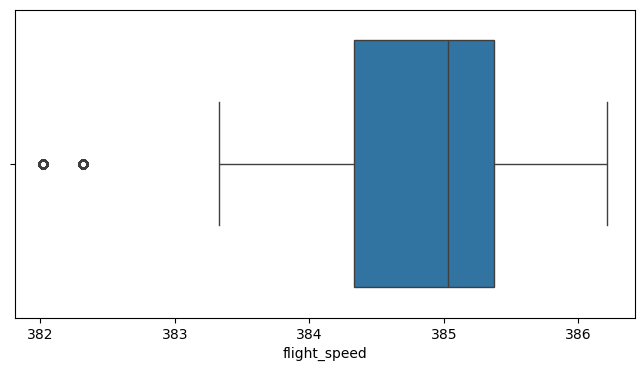

In [52]:
plt.figure(figsize=(8,4))
sns.boxplot(x=flights_filtered['flight_speed'])

A few outliers can be observed in the box plot which could be due to valid real-world scenarios like bad weather conditions etc.

In [53]:
df = flights_filtered.copy()

### **One-hot encoding**

In [54]:
# Apply one-hot encoding to specific categorical columns
df = pd.get_dummies(
    df,
    columns=['from', 'destination', 'flightType', 'agency'],
    prefix=['from', 'destination', 'flightType', 'agency']
)

# Display the first few rows of the transformed DataFrame
df.head()


,time,distance,week_day,week_no,day,month,year,price,flight_speed,from_Aracaju (SE),...,destination_Recife (PE),destination_Rio de Janeiro (RJ),destination_Salvador (BH),destination_Sao Paulo (SP),flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,1.76,676.53,3,39,26,9,2019,1434.38,384.39,False,...,False,False,False,False,False,True,False,False,True,False
1,1.76,676.53,0,40,30,9,2019,1292.29,384.39,False,...,True,False,False,False,False,True,False,False,True,False
2,1.66,637.56,3,40,3,10,2019,1487.52,384.07,False,...,False,False,False,False,False,True,False,True,False,False
3,1.66,637.56,4,40,4,10,2019,1127.36,384.07,False,...,False,False,False,False,False,True,False,True,False,False
4,2.16,830.86,3,41,10,10,2019,1684.05,384.66,True,...,False,False,True,False,False,True,False,True,False,False


In [55]:
df.shape

(271888, 33)

---
## **Feature Selection**

#### Feature Selection Using Statistical Test - ANOVA F-Test

In [57]:
final_df1 = df.copy()

In [58]:
final_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             271888 non-null  float64
 1   distance                         271888 non-null  float64
 2   week_day                         271888 non-null  int32  
 3   week_no                          271888 non-null  UInt32 
 4   day                              271888 non-null  int32  
 5   month                            271888 non-null  int32  
 6   year                             271888 non-null  int32  
 7   price                            271888 non-null  float64
 8   flight_speed                     271888 non-null  float64
 9   from_Aracaju (SE)                271888 non-null  bool   
 10  from_Brasilia (DF)               271888 non-null  bool   
 11  from_Campo Grande (MS)           271888 non-null  bool   
 12  fr

In [59]:
final_df1 = final_df1.drop(columns=['time','flight_speed','month','year','distance'],axis=1)

In [61]:
final_df1.shape

(271888, 28)

In [62]:
# Separate features (X) and target variable (y)
X = final_df1.drop('price', axis=1)  # Features
y = final_df1['price']                # Target variable
 
# Get the numerical features in X
num_features = X.select_dtypes(include=['number']).columns

# If the number of features is less than k, adjust k to the number of available features
k = min(27, len(num_features)) 

# ANOVA F-test for numerical features
f_selector = SelectKBest(score_func=f_classif, k=k)
f_selector.fit(X[num_features], y)

# Get indices of top k features
numerical_top_indices = f_selector.get_support(indices=True)

# Combine top indices
top_indices = list(numerical_top_indices)

# Get top k feature names
top_features = X.columns[top_indices]

# Display top k features
print("Top k selected features:")
print(top_features)


Top k selected features:
Index(['week_day', 'week_no', 'day'], dtype='object')


#### Checking and treating Multicollinearity using VIF

In [65]:
# Define the function to calculate VIF
def calc_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# Filter numerical columns excluding boolean columns
numerical_columns = flights_filtered.select_dtypes(include=[np.number]).columns

# List of valid numerical columns
valid_columns = ['time', 'distance', 'week_day', 'week_no', 'day', 'month', 'year', 'price', 'flight_speed']

# Ensure all valid columns are numerical
filtered_df = flights_filtered[valid_columns]

# Convert 'UInt32' columns to float64
if 'week_no' in filtered_df.columns:
    filtered_df['week_no'] = filtered_df['week_no'].astype(float)

# Drop any constant or low-variance columns
filtered_df = filtered_df.loc[:, (filtered_df.var() > 0)]

# Check for any missing or infinite values
filtered_df = filtered_df.replace([np.inf, -np.inf], np.nan).dropna()

# Debugging: Inspect the filtered DataFrame
print("Filtered DataFrame Info:")
print(filtered_df.info())


Filtered DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   time          271888 non-null  float64
 1   distance      271888 non-null  float64
 2   week_day      271888 non-null  int32  
 3   week_no       271888 non-null  float64
 4   day           271888 non-null  int32  
 5   month         271888 non-null  int32  
 6   year          271888 non-null  int32  
 7   price         271888 non-null  float64
 8   flight_speed  271888 non-null  float64
dtypes: float64(5), int32(4)
memory usage: 14.5 MB
None


In [66]:
# Calculate VIF
try:
    vif_result = calc_vif(filtered_df)
    print(vif_result)
except Exception as e:
    print(f"Error calculating VIF: {e}")

        Feature           VIF
0          time  1.546121e+06
1      distance  1.548498e+06
2      week_day  5.160073e+00
3       week_no  7.255121e+01
4           day  4.427838e+00
5         month  8.001092e+01
6          year  7.911799e+05
7         price  1.362082e+01
8  flight_speed  7.937973e+05


In [67]:
X.rename(columns={'from_Sao Paulo (SP)':'from_Sao_Paulo (SP)','from_Rio de Janeiro (RJ)':'from_Rio_de_Janeiro (RJ)','from_Campo Grande (MS)':'from_Campo_Grande (MS)',
                                  'destination_Sao Paulo (SP)':'destination_Sao_Paulo (SP)','destination_Rio de Janeiro (RJ)':'destination_Rio_de_Janeiro (RJ)','destination_Campo Grande (MS)':'destination_Campo_Grande (MS)'},inplace=True)

In [68]:
features_ordering=['from_Florianopolis (SC)',
                     'from_Sao_Paulo (SP)',
                     'from_Salvador (BH)',
                     'from_Brasilia (DF)',
                     'from_Rio_de_Janeiro (RJ)',
                     'from_Campo_Grande (MS)',
                     'from_Aracaju (SE)',
                     'from_Natal (RN)',
                     'from_Recife (PE)',
                     'destination_Florianopolis (SC)',
                     'destination_Sao_Paulo (SP)',
                     'destination_Salvador (BH)',
                     'destination_Brasilia (DF)',
                     'destination_Rio_de_Janeiro (RJ)',
                     'destination_Campo_Grande (MS)',
                     'destination_Aracaju (SE)',
                     'destination_Natal (RN)',
                     'destination_Recife (PE)',
                     'flightType_economic',
                     'flightType_firstClass',
                     'flightType_premium',
                     'agency_Rainbow',
                     'agency_CloudFy',
                     'agency_FlyingDrops',
                     'week_no',
                     'week_day']

In [69]:
# Ordering features based on flask output
final_features= X[features_ordering]

In [70]:
# Final independent features
X1 = final_features

# Target variable
y1 = y

# Split the data into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

scaler_new = StandardScaler()

X_train1 = scaler_new.fit_transform(X_train1)
X_test1 = scaler_new.transform(X_test1)


In [71]:
final_features.columns

Index(['from_Florianopolis (SC)', 'from_Sao_Paulo (SP)', 'from_Salvador (BH)',
       'from_Brasilia (DF)', 'from_Rio_de_Janeiro (RJ)',
       'from_Campo_Grande (MS)', 'from_Aracaju (SE)', 'from_Natal (RN)',
       'from_Recife (PE)', 'destination_Florianopolis (SC)',
       'destination_Sao_Paulo (SP)', 'destination_Salvador (BH)',
       'destination_Brasilia (DF)', 'destination_Rio_de_Janeiro (RJ)',
       'destination_Campo_Grande (MS)', 'destination_Aracaju (SE)',
       'destination_Natal (RN)', 'destination_Recife (PE)',
       'flightType_economic', 'flightType_firstClass', 'flightType_premium',
       'agency_Rainbow', 'agency_CloudFy', 'agency_FlyingDrops', 'week_no',
       'week_day'],
      dtype='object')

---
## **Model Building, Training, Cross-Validation, Hyperparameter Tuning & Evaluation**

### **Linear Regression - Baseline Model**

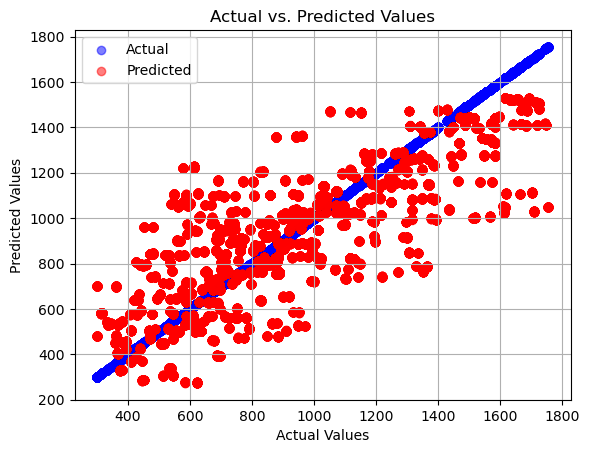

In [72]:
# Create and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train1, y_train1)

# Make predictions on the test set
y_pred1 = linear_model.predict(X_test1)

# Evaluate the model
mae_lr = mean_absolute_error(y_test1, y_pred1)
mse_lr = mean_squared_error(y_test1, y_pred1)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test1, y_pred1)

# Calculate adjusted R-squared for linear regression
n = X_test1.shape[0]
p = X_test1.shape[1]

# Calculate adjusted R-squared
adj_r2_lr = 1 - ((1 - r2_lr) * (n - 1) / (n - p - 1))

# Visualize the model fit
plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  
plt.scatter(y_test1, y_pred1, c='r', label='Predicted', alpha=0.5)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


**Model Evaluation**

In [74]:
model_result = pd.DataFrame([['Linear Regression - Baseline', mse_lr,rmse_lr,mae_lr, r2_lr,adj_r2_lr]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,47023.433215,216.848872,165.35558,0.643138,0.642967


### **Linear Regression - Hyperparameter Tuning**

In [75]:
# Define hyperparameters and their potential values
param_grid_linear = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Create a GridSearchCV object for Linear Regression
grid_lr = GridSearchCV(linear_model, param_grid_linear, cv=3, scoring='neg_mean_squared_error')
grid_lr.fit(X_train1, y_train1)

# Get the best hyperparameters for Linear Regression
best_linear_reg = grid_lr.best_estimator_

# Perform grid search
best_linear_reg.fit(X_train1, y_train1)

LinearRegression()

In [76]:
# Print the best hyperparameters
print("Best Hyperparameters for Linear Regression:", grid_lr.best_estimator_)

Best Hyperparameters for Linear Regression: LinearRegression()


**Model Evaluation**

In [77]:
# Evaluate the model
y_pred_linear_tuned = best_linear_reg.predict(X_test1)

mae_linear_tuned = mean_absolute_error(y_test1, y_pred_linear_tuned )
mse_linear_tuned = mean_squared_error(y_test1, y_pred_linear_tuned )
rmse_linear_tuned = np.sqrt(mse_linear_tuned)
r2_linear_tuned = r2_score(y_test1, y_pred_linear_tuned )
adj_r2_linear_tuned = 1 - ((1 - r2_linear_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Linear Regression - Tuned',  mse_linear_tuned,rmse_linear_tuned,mae_linear_tuned, r2_linear_tuned,adj_r2_linear_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,47023.433215,216.848872,165.35558,0.643138,0.642967
1,Linear Regression - Tuned,47023.433215,216.848872,165.35558,0.643138,0.642967


### **Lasso Regression - Baseline Model**

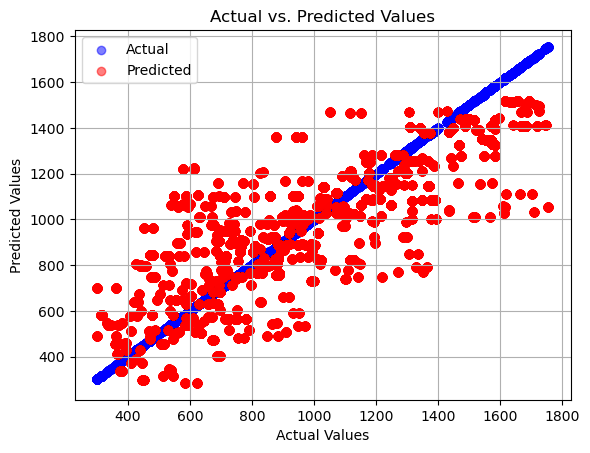

In [80]:
# Basic Lasso Regression
lasso_model = Lasso() 
lasso_model.fit(X_train1, y_train1)

# Evaluate the model
y_pred_lasso = lasso_model.predict(X_test1)

mae_lasso = mean_absolute_error(y_test1, y_pred_lasso)
mse_lasso = mean_squared_error(y_test1, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test1, y_pred_lasso)
adj_r2_lasso = 1 - ((1 - r2_lasso) * (n - 1) / (n - p - 1))

# Visualize model fit
plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  
plt.scatter(y_test1, y_pred_lasso, c='r', label='Predicted', alpha=0.5)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

**Model Evaluation**

In [81]:
model = pd.DataFrame([['Lasso Regression - Baseline',  mse_lasso,rmse_lasso,mae_lasso, r2_lasso,adj_r2_lasso]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,47023.433215,216.848872,165.35558,0.643138,0.642967
1,Linear Regression - Tuned,47023.433215,216.848872,165.35558,0.643138,0.642967
2,Lasso Regression - Baseline,47030.031372,216.864085,165.62706,0.643088,0.642917


### **Lasso Regression - Hyperparameter Tuning**

In [82]:
# Define hyperparameters and their potential values
param_grid = {
    'alpha': [0.001,0.01, 0.1,0.3,0.5,0.6,0.8, 1.0,10] 
}

# Create a GridSearchCV object for Lasso Regression
grid_search_lasso = GridSearchCV(lasso_model, param_grid, cv=3, scoring='neg_mean_squared_error')

# Perform grid search
grid_search_lasso.fit(X_train1, y_train1)

# Get the best hyperparameters for Lasso Regression
best_lasso_model = grid_search_lasso.best_estimator_

# Fit the best model to the training data
best_lasso_model.fit(X_train1, y_train1)

Lasso(alpha=0.01)

In [83]:
# Print the best hyperparameters
print("Best Hyperparameters for Lasso Regression:", grid_search_lasso.best_params_)

Best Hyperparameters for Lasso Regression: {'alpha': 0.01}


**Model Evaluation**

In [84]:
# Evaluate the model
y_pred_lasso_tuned = best_lasso_model.predict(X_test1)

mae_lasso_tuned = mean_absolute_error(y_test1, y_pred_lasso_tuned )
mse_lasso_tuned = mean_squared_error(y_test1, y_pred_lasso_tuned )
rmse_lasso_tuned = np.sqrt(mse_lasso_tuned)
r2_lasso_tuned = r2_score(y_test1, y_pred_lasso_tuned )
adj_r2_lasso_tuned = 1 - ((1 - r2_lasso_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Lasso Regression - Tuned',  mse_lasso_tuned,rmse_lasso_tuned,mae_lasso_tuned, r2_lasso_tuned,adj_r2_lasso_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,47023.433215,216.848872,165.355580,0.643138,0.642967
1,Linear Regression - Tuned,47023.433215,216.848872,165.355580,0.643138,0.642967
2,Lasso Regression - Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917
3,Lasso Regression - Tuned,47023.319846,216.848610,165.357816,0.643139,0.642968


### **Ridge Regression - Baseline Model**

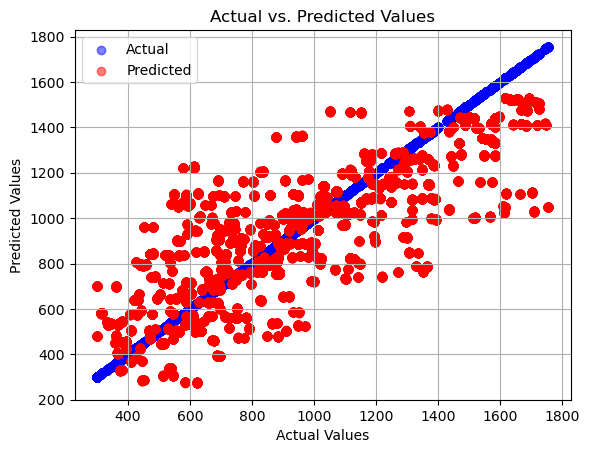

In [85]:
# Basic Ridge Regression
ridge_model = Ridge() 
ridge_model.fit(X_train1, y_train1)

# Evaluate the model
y_pred_ridge = ridge_model.predict(X_test1)

mae_ridge = mean_absolute_error(y_test1, y_pred_ridge)
mse_ridge = mean_squared_error(y_test1,y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test1, y_pred_ridge)
adj_r2_ridge = 1 - ((1 - r2_ridge) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  
plt.scatter(y_test1, y_pred_ridge, c='r', label='Predicted', alpha=0.5)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### **Model Evaluation**

In [86]:
model = pd.DataFrame([['Ridge Regression - Baseline',  mse_ridge,rmse_ridge,mae_ridge, r2_ridge,adj_r2_ridge]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,47023.433215,216.848872,165.355580,0.643138,0.642967
1,Linear Regression - Tuned,47023.433215,216.848872,165.355580,0.643138,0.642967
2,Lasso Regression - Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917
3,Lasso Regression - Tuned,47023.319846,216.848610,165.357816,0.643139,0.642968
4,Ridge Regression - Baseline,47023.430658,216.848866,165.355628,0.643138,0.642967


### **Ridge Regression - Hyperparameter Tuning**

In [87]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'alpha': [0.001,0.01, 0.1,0.3,0.5,0.6,0.8, 1.0,10,20,50]  # Adjust the range of alpha values as needed
}

# Create a GridSearchCV object for Ridge Regression
grid_search_ridge = GridSearchCV(ridge_model, param_grid, cv=3, scoring='neg_mean_squared_error')

grid_search_ridge.fit(X_train1, y_train1)

# Get the best hyperparameters for Ridge Regression
best_ridge_model = grid_search_ridge.best_estimator_

# Perform grid search
best_ridge_model.fit(X_train1, y_train1)

Ridge(alpha=20)

In [88]:
# Print the best hyperparameters
print("Best Hyperparameters for Ridge Regression:", grid_search_ridge.best_estimator_)

Best Hyperparameters for Ridge Regression: Ridge(alpha=20)


**Model Evaluation**

In [89]:
# Evaluate the model
y_pred_ridge_tuned = best_ridge_model.predict(X_test1)

mae_ridge_tuned = mean_absolute_error(y_test1, y_pred_ridge_tuned )
mse_ridge_tuned = mean_squared_error(y_test1, y_pred_ridge_tuned )
rmse_ridge_tuned = np.sqrt(mse_ridge_tuned)
r2_ridge_tuned = r2_score(y_test1, y_pred_ridge_tuned )
adj_r2_ridge_tuned = 1 - ((1 - r2_ridge_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Ridge Regression - Tuned',  mse_ridge_tuned,rmse_ridge_tuned,mae_ridge_tuned, r2_ridge_tuned,adj_r2_ridge_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,47023.433215,216.848872,165.355580,0.643138,0.642967
1,Linear Regression - Tuned,47023.433215,216.848872,165.355580,0.643138,0.642967
2,Lasso Regression - Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917
3,Lasso Regression - Tuned,47023.319846,216.848610,165.357816,0.643139,0.642968
4,Ridge Regression - Baseline,47023.430658,216.848866,165.355628,0.643138,0.642967
5,Ridge Regression - Tuned,47023.382528,216.848755,165.356538,0.643138,0.642968


### **Decision Tree - Baseline Model**

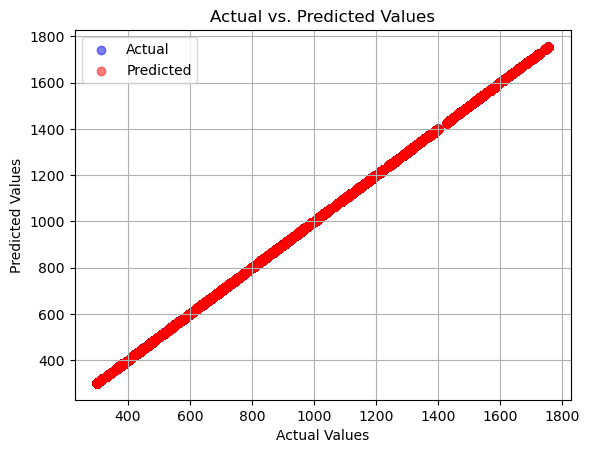

In [90]:
# Initialize the Decision Tree Regressor model
decision_tree_reg = DecisionTreeRegressor(random_state=42)

# Fit the model on the training data
decision_tree_reg.fit(X_train1, y_train1)

# Make predictions on the test data
y_pred_decision = decision_tree_reg.predict(X_test1)

# Evaluate the model
mse_dt = mean_squared_error(y_test1, y_pred_decision)
rmse_dt = mse_dt**0.5
mae_dt = mean_absolute_error(y_test1, y_pred_decision)
r2_dt = r2_score(y_test1, y_pred_decision)
adj_r2_dt = 1 - ((1 - r2_dt) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  
plt.scatter(y_test1, y_pred_decision, c='r', label='Predicted', alpha=0.5) 
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


**Model Evaluation**

In [93]:
model = pd.DataFrame([['Decision Tree - Baseline',  mse_dt,rmse_dt,mae_dt, r2_dt,adj_r2_dt]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000


### **Decision Tree - Hyperparameter Tuning**

In [92]:
# Define hyperparameters and their potential values
param_grid_dt = {
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [15,30,45],
    'min_samples_split': [2,3,5],
    'max_features': [15,27,'sqrt'],
    'ccp_alpha' :[1,2]
}

# Create a GridSearchCV object for Decision Tree Regressor
grid_search_dt = GridSearchCV(decision_tree_reg, param_grid_dt, cv=3, scoring='neg_mean_squared_error')
grid_search_dt.fit(X_train1, y_train1)

# Get the best hyperparameters for Decision Tree Regressor
best_decision_tree_model = grid_search_dt.best_estimator_

In [94]:
# Print the best hyperparameters
print("Best Hyperparameters for Decision Tree:", grid_search_dt.best_estimator_)

Best Hyperparameters for Decision Tree: DecisionTreeRegressor(ccp_alpha=1, criterion='friedman_mse', max_depth=30,
                      max_features=27, min_samples_split=3, random_state=42)


**Model Evaluation**

In [95]:
# Evaluate the best model
y_pred_dt_tuned = best_decision_tree_model.predict(X_test1)

mae_dt_tuned = mean_absolute_error(y_test1, y_pred_dt_tuned)
mse_dt_tuned = mean_squared_error(y_test1, y_pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mse_dt_tuned)
r2_dt_tuned = r2_score(y_test1, y_pred_dt_tuned)
adj_r2_dt_tuned = 1 - ((1 - r2_dt_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Decision Tree - Tuned',  mse_dt_tuned,rmse_dt_tuned,mae_dt_tuned, r2_dt_tuned,adj_r2_dt_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
8,Decision Tree - Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663


In [99]:
model_result = model_result.drop(index=6)

In [100]:
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
7,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
8,Decision Tree - Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663


**Feature Importance - Decision Tree Tuned**

In [96]:
# Get feature importances
feature_importances_dt_reg = best_decision_tree_model.feature_importances_

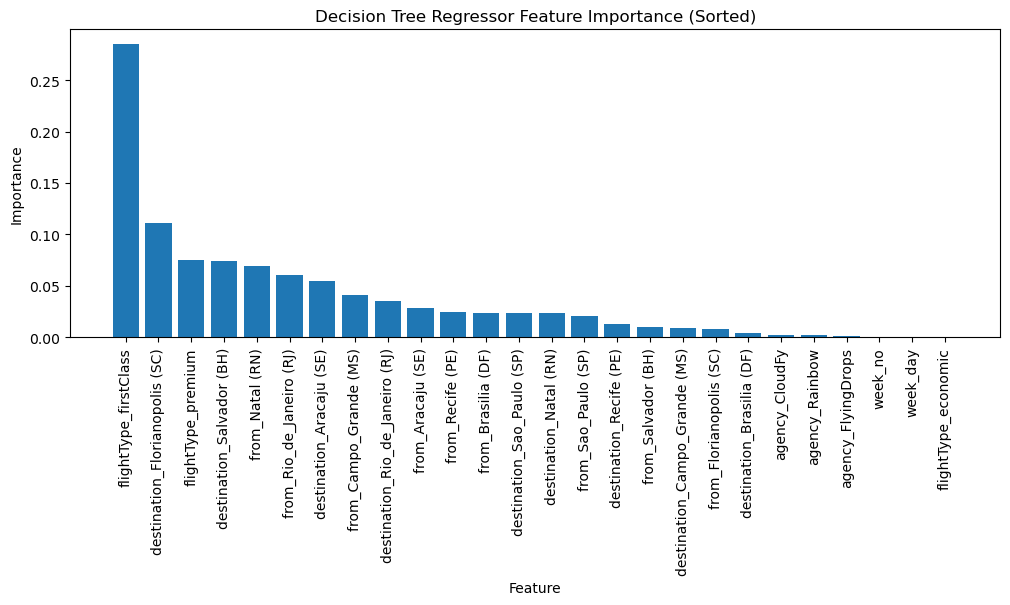

In [97]:
# Define feature names
feature_names = X1.columns.tolist() 

# Zip feature names and importances
feature_importances_sorted = sorted(zip(feature_names, feature_importances_dt_reg), key=lambda x: x[1], reverse=True)
sorted_features, sorted_importances = zip(*feature_importances_sorted)

# Create bar plot
plt.figure(figsize=(12, 4))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Decision Tree Regressor Feature Importance (Sorted)')
plt.show()


### **Random Forest - Baseline Model**

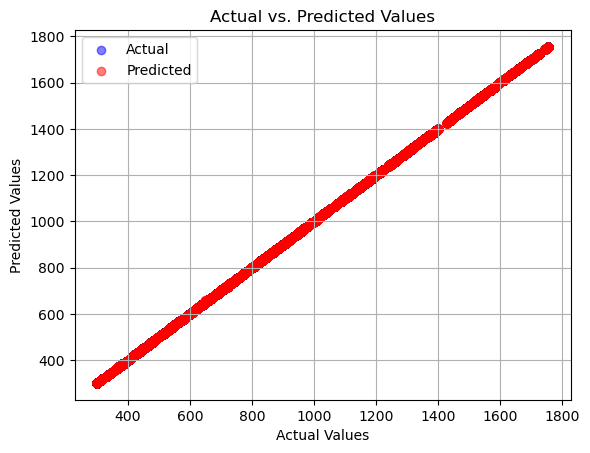

In [101]:
# Create and train the Random Forest Regression model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train1, y_train1)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test1)

# Evaluate the model
mae_rf = mean_absolute_error(y_test1,y_pred_rf)
mse_rf = mean_squared_error(y_test1, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test1, y_pred_rf)
adj_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))

# Visualize the fit
plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  
plt.scatter(y_test1, y_pred_rf, c='r', label='Predicted', alpha=0.5)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

**Model Evaluation**

In [102]:
model = pd.DataFrame([['Random Forest - Baseline',  mse_rf,rmse_rf,mae_rf, r2_rf,adj_r2_rf]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree - Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest - Baseline,2.528445e-02,1.590108e-01,7.715830e-03,1.000000,1.000000


### **Random Forest - Hyperparameter tuning**

In [103]:
# Define hyperparameters and their potential values
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [1,5,10],
    'min_samples_split': [2, 5,10],
    'max_features': ['sqrt',27],
    'n_jobs': [2]
}

# Create a GridSearchCV object for Random Forest Regression
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=3, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train1, y_train1)

# Get the best hyperparameters for Random Forest Regression
best_rf_model = grid_search_rf.best_estimator_

In [104]:
grid_search_rf.best_estimator_

RandomForestRegressor(max_depth=10, max_features='sqrt', n_jobs=2,
                      random_state=42)

In [105]:
# Print the best hyperparameters
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_estimator_)

Best Hyperparameters for Random Forest: RandomForestRegressor(max_depth=10, max_features='sqrt', n_jobs=2,
                      random_state=42)


**Model Evaluation**

In [106]:
# Evaluate the best model
y_pred_rf_tuned = best_rf_model.predict(X_test1)

mae_rf_tuned = mean_absolute_error(y_test1, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test1, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test1, y_pred_rf_tuned)
adj_r2_rf_tuned = 1 - ((1 - r2_rf_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Random Forest - Tuned',  mse_rf_tuned,rmse_rf_tuned,mae_rf_tuned, r2_rf_tuned,adj_r2_rf_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree - Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest - Baseline,2.528445e-02,1.590108e-01,7.715830e-03,1.000000,1.000000
9,Random Forest - Tuned,1.785410e+04,1.336192e+02,9.975540e+01,0.864505,0.864440


**Feature Importance - Random Forest**

In [107]:
feature_importances_rf_reg = best_rf_model.feature_importances_

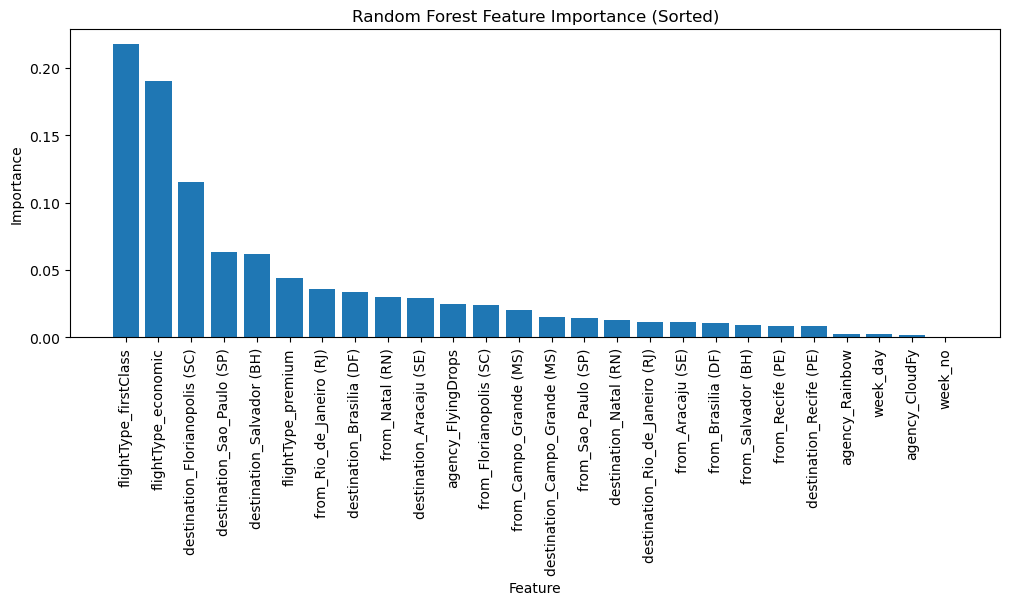

In [108]:
# Define feature names
feature_names = X1.columns.tolist()  

# Zip feature names and importances
feature_importances_sorted = sorted(zip(feature_names, feature_importances_rf_reg), key=lambda x: x[1], reverse=True)
sorted_features, sorted_importances = zip(*feature_importances_sorted)

# Create bar plot
plt.figure(figsize=(12, 4))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance (Sorted)')
plt.show()


### **XGBoost - Baseline Model**

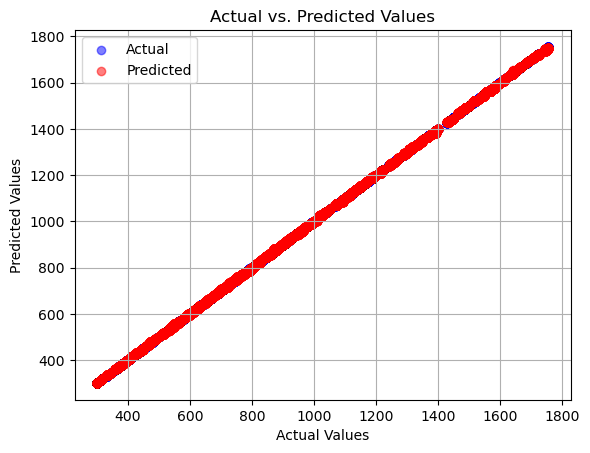

In [110]:
# Define Basic XGBoost regressor
xgb_regressor_model = XGBRegressor(random_state=42)
xgb_regressor_model.fit(X_train1, y_train1)

# Evaluate the model
y_pred_xgb = xgb_regressor_model.predict(X_test1)

mae_xgb = mean_absolute_error(y_test1, y_pred_xgb)
mse_xgb = mean_squared_error(y_test1,y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test1, y_pred_xgb)
adj_r2_xgb = 1 - ((1 - r2_xgb) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  
plt.scatter(y_test1, y_pred_xgb, c='r', label='Predicted', alpha=0.5)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

**Model Evaluation**

In [111]:
model = pd.DataFrame([['XGBoost - Baseline',  mse_xgb,rmse_xgb,mae_xgb, r2_xgb,adj_r2_xgb]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree - Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest - Baseline,2.528445e-02,1.590108e-01,7.715830e-03,1.000000,1.000000
9,Random Forest - Tuned,1.785410e+04,1.336192e+02,9.975540e+01,0.864505,0.864440


### **XG Boost - Hyperparameter Tuning**

In [113]:
param_grid = {
    'n_estimators': [3, 5],
    'max_depth': [35, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.1]
}

# Perform RandomizedSearchCV for hyperparameter tuning
random_search_xgb = RandomizedSearchCV(estimator=xgb_regressor_model, param_distributions=param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42)

# Fit the model
random_search_xgb.fit(X_train1, y_train1)

# Get the best model and parameters
best_xgb_regressor = random_search_xgb.best_estimator_
print("Best hyperparameters:", random_search_xgb.best_params_)


Best hyperparameters: {'subsample': 1.0, 'n_estimators': 5, 'max_depth': 50, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [114]:
random_search_xgb.best_params_

{'subsample': 1.0,
 'n_estimators': 5,
 'max_depth': 50,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [115]:
# Print the best hyperparameters
print("Best Hyperparameters for XGBoost Regressor:", random_search_xgb.best_params_)

Best Hyperparameters for XGBoost Regressor: {'subsample': 1.0, 'n_estimators': 5, 'max_depth': 50, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


**Model Evaluation**

In [116]:
# Evaluate the best model
y_pred_xgb_tuned = best_xgb_regressor.predict(X_test1)

mae_xgb_tuned = mean_absolute_error(y_test1, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test1, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test1, y_pred_xgb_tuned)
adj_r2_xgb_tuned = 1 - ((1 - r2_xgb_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['XGBoost Model - Tuned',  mse_xgb_tuned,rmse_xgb_tuned,mae_xgb_tuned, r2_xgb_tuned,adj_r2_xgb_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
1,Linear Regression - Tuned,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
2,Lasso Regression - Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression - Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression - Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression - Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree - Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest - Baseline,2.528445e-02,1.590108e-01,7.715830e-03,1.000000,1.000000
9,Random Forest - Tuned,1.785410e+04,1.336192e+02,9.975540e+01,0.864505,0.864440


**Feature Importance - XGBoost Tuned**

In [117]:
feature_importances_xgb_reg = best_xgb_regressor.feature_importances_

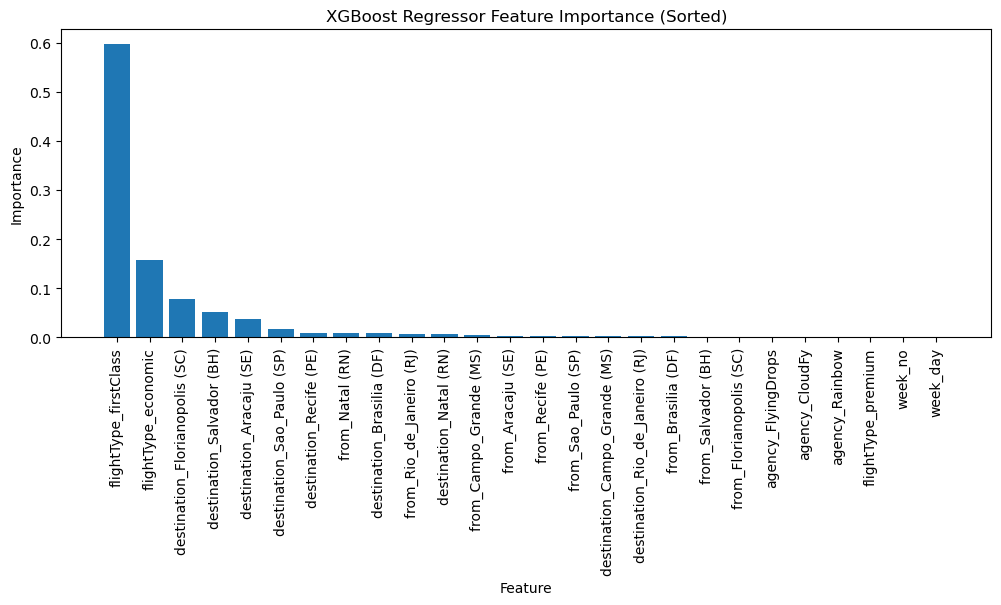

In [118]:
# Define feature names
feature_names = X1.columns.tolist()  

# Zip feature names and importances
feature_importances_sorted = sorted(zip(feature_names, feature_importances_xgb_reg), key=lambda x: x[1], reverse=True)
sorted_features, sorted_importances = zip(*feature_importances_sorted)

# Create bar plot
plt.figure(figsize=(12, 4))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('XGBoost Regressor Feature Importance (Sorted)')
plt.show()

---
### **The best model among all the ones experimented with is the ***RandomForestRegressor Tuned Model***.**

In [119]:
y_pred_rf = best_rf_model.predict(X_test1)
y_pred_rf_tr = best_rf_model.predict(X_train1) 

In [120]:
#Training data Metrics
mse_rf_tr = mean_squared_error(y_train1, y_pred_rf_tr)
rmse_rf_tr = np.sqrt(mse_rf_tr)
mae_rf_tr = mean_absolute_error(y_train1, y_pred_rf_tr)
r2_rf_tr = r2_score(y_train1, y_pred_rf_tr)
adj_r2_rf_tr = 1 - ((1 - r2_rf_tr) * (n - 1) / (n - p - 1))

#Test data Metrics
mse_rf = mean_squared_error(y_test1, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test1, y_pred_rf)
r2_rf = r2_score(y_test1, y_pred_rf)
adj_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))

***Following are the final evaluation metrics on the Train and Test sets.***

In [121]:
print("Random Forest Regression Train Metrics:\n")
print("Mean Squared Error (MSE):", mse_rf_tr)
print("Root Mean Squared Error (RMSE):", rmse_rf_tr)
print("Mean Absolute Error (MAE):", mae_rf_tr)
print("R-squared (R2) Score:", r2_rf_tr)
print("Adjusted R-squared (Adj R2) Score:", adj_r2_rf_tr)


print("\nRandom Forest Regression Test Metrics:\n")
print("Mean Squared Error (MSE):", mse_rf)
print("Root Mean Squared Error (RMSE):", rmse_rf)
print("Mean Absolute Error (MAE):", mae_rf)
print("R-squared (R2) Score:", r2_rf)
print("Adjusted R-squared (Adj R2) Score:", adj_r2_rf)


Random Forest Regression Train Metrics:

Mean Squared Error (MSE): 17781.52552350567
Root Mean Squared Error (RMSE): 133.34738663920515
Mean Absolute Error (MAE): 99.6001970239004
R-squared (R2) Score: 0.8644125929421903
Adjusted R-squared (Adj R2) Score: 0.8643477317145496

Random Forest Regression Test Metrics:

Mean Squared Error (MSE): 17854.100810321474
Root Mean Squared Error (RMSE): 133.61923817445404
Mean Absolute Error (MAE): 99.75540163905347
R-squared (R2) Score: 0.8645047529936177
Adjusted R-squared (Adj R2) Score: 0.8644399358527709


#### **Benchmark Model**

In [122]:
# Benchmark Model on the basis on RMSE metric
model_result[model_result['RMSE']==model_result['RMSE'].min()]

,Model,MSE,RMSE,MAE,R2,adj_r2
6,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.0,1.0


In [123]:
# Benchmark Model on the basis on Adjusted R2 square metric
model_result[model_result['adj_r2']==model_result['adj_r2'].max()]

,Model,MSE,RMSE,MAE,R2,adj_r2
6,Decision Tree - Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.0,1.0


**Evaluation / Conclusion:**

Based purely on evaluation metrics, the Decision Tree (baseline) model achieves the lowest RMSE and the highest R-squared. However, decision trees are prone to overfitting and often fail to generalize well to unseen data. Therefore, despite its strong in-sample performance, the final model selected for this dataset is the **Random Forest Regressor**.

*Random Forest mitigates overfitting by averaging predictions across multiple decision trees, which reduces variance and improves generalization*. As a result, it offers a better trade-off between performance and robustness, achieving a **low RMSE** and an **R-squared of 0.86**, making it more reliable for real-world predictions.

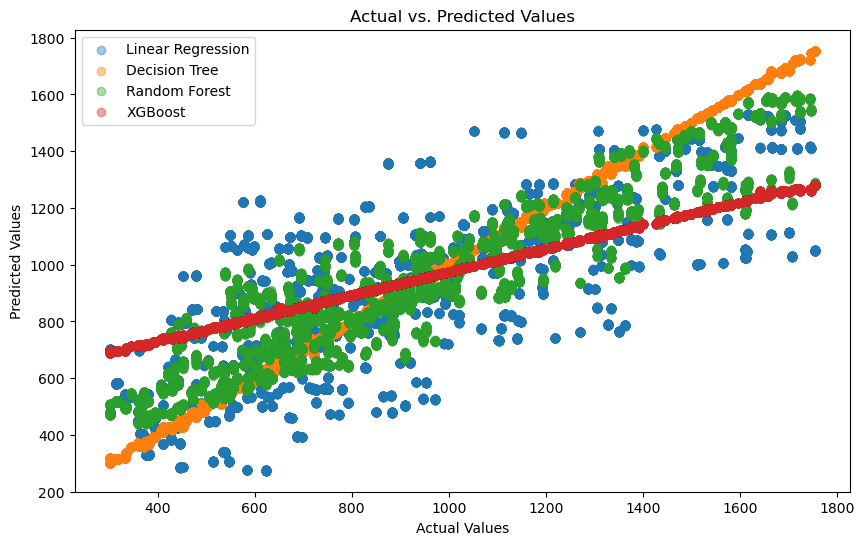

In [124]:
plt.figure(figsize=(10, 6))

# Linear Regression
plt.scatter(y_test1, y_pred_linear_tuned, label='Linear Regression', alpha=0.4)

# Decision Tree Regressor
plt.scatter(y_test1, y_pred_dt_tuned, label='Decision Tree', alpha=0.4)

# Random Forest Regressor
plt.scatter(y_test1, y_pred_rf_tuned, label='Random Forest', alpha=0.4)

# XGBoost Regressor
plt.scatter(y_test1, y_pred_xgb_tuned, label='XGBoost', alpha=0.4)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend()
plt.show()


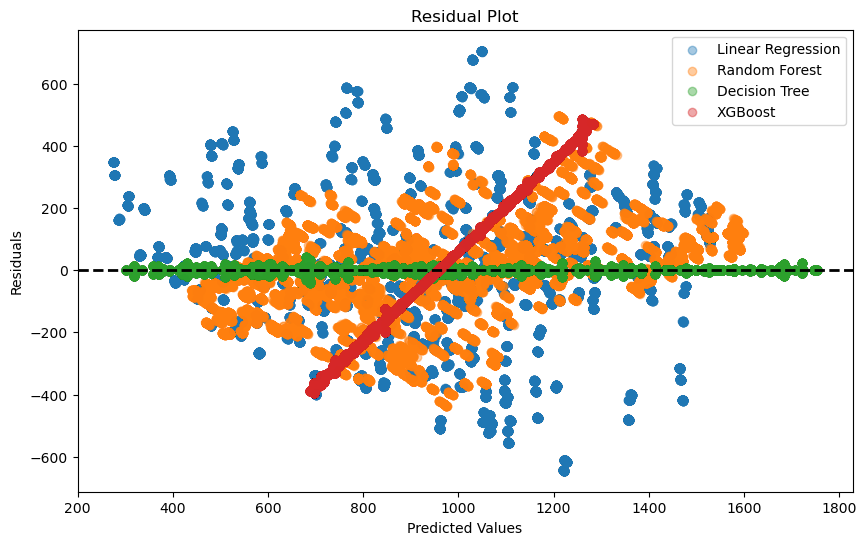

In [125]:
plt.figure(figsize=(10, 6))

# Linear Regression Residuals
residuals_lr = y_test1 - y_pred_linear_tuned
plt.scatter(y_pred_linear_tuned, residuals_lr, label='Linear Regression', alpha=0.4)

# Random Forest Regressor Residuals
residuals_rf = y_test1 - y_pred_rf_tuned
plt.scatter(y_pred_rf_tuned, residuals_rf, label='Random Forest', alpha=0.4)

# Decision Tree Regressor Residuals
residuals_dt = y_test1 -y_pred_dt_tuned
plt.scatter(y_pred_dt_tuned, residuals_dt, label='Decision Tree', alpha=0.4)

# XGBoost Regressor Residuals
residuals_xgb = y_test1 -y_pred_xgb_tuned
plt.scatter(y_pred_xgb_tuned, residuals_xgb, label='XGBoost', alpha=0.4)

plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()
plt.show()

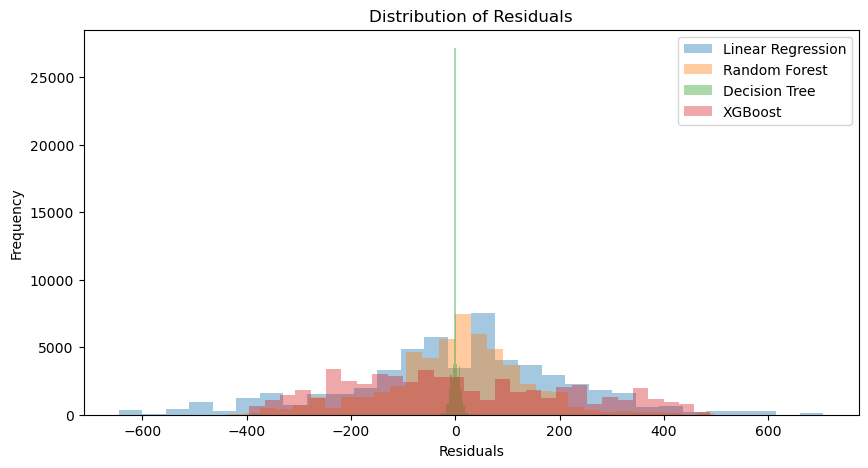

In [126]:
plt.figure(figsize=(10, 5))

# Linear Regression Residuals Distribution
plt.hist(residuals_lr, bins=30, alpha=0.4, label='Linear Regression')

# Random Forest Regressor Residuals Distribution
plt.hist(residuals_rf, bins=30, alpha=0.4, label='Random Forest')

# Decision Tree Regressor Residuals Distribution
plt.hist(residuals_dt, bins=30, alpha=0.4, label='Decision Tree')

# XGBoost Regressor Residuals Distribution
plt.hist(residuals_xgb, bins=30, alpha=0.4, label='XGBoost')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.legend()
plt.show()

---
## **Conclusion**

This project successfully demonstrates the development of a robust flight price prediction system by combining strong machine learning fundamentals with practical MLOps implementation. While multiple regression models were explored, the **Random Forest Regressor** emerged as the most reliable choice, offering a strong balance between accuracy and generalization.

Beyond modeling, the project highlights the importance of deploying scalable and production-ready solutions through tools such as Flask, Docker, Kubernetes, Airflow, and MLflow. This end-to-end approach ensures that the model is not only accurate but also maintainable, reproducible, and ready for real-world applications.

The project reflects a complete machine learning lifecycle—transforming raw data into actionable insights and delivering them through a scalable and automated system.


---

## **Additional Notes**

### **Flask Building**

Things we need to do:

- **Flask Web Application**: We create a Flask web application to serve as an API endpoint.
- **Load Trained Model**: We load a trained regression model.
- **Prediction Function**: We define a function (predict_value) to make predictions using the loaded model.
- **User Input Processing**: In the /predict route, we collect user input data from an HTML form, including price, travel details, and other parameters.
- **Data Preparation**: We prepare the user input data and convert it into a format suitable for making predictions.
- **Prediction**: Using the loaded model, we make predictions based on the user's input.
- **JSON Response**: We return the prediction result as a JSON response to the API request.
- **HTML Form**: If the request is a GET request, we display an HTML form to collect user input.
- **Styling**: HTML form and add CSS styling can be customized to make it visually appealing.
- **Run the Flask App**: The Flask app is run, allowing users to access it and receive predictions through API requests.

In [128]:
pickle.dump(scaler_new,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/scaling.pkl','wb'))
pickle.dump(best_rf_model,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/rf_model.pkl','wb'))

In [129]:
pickle.dump(best_linear_reg,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/lr_model.pkl','wb'))
pickle.dump(best_lasso_model,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/lasso_model.pkl','wb'))
pickle.dump(best_ridge_model,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/ridge_model.pkl','wb'))
pickle.dump(best_decision_tree_model,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/dt_model.pkl','wb'))
pickle.dump(best_xgb_regressor,open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/xgb_model.pkl','wb'))

In [130]:
with open("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/scaling.pkl", "wb") as f:
    pickle.dump(scaler_new, f)

In [135]:
scaler_model=pickle.load(open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/scaling.pkl','rb'))
rf_model=pickle.load(open('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/rf_model.pkl','rb'))

In [137]:
# Create a function for prediction
def predict_price(input_data, model,scaler):
    # Prepare the input data

    # Initialize an empty DataFrame
    df_input2 = pd.DataFrame([input_data])

    # Independent features
    X = df_input2

    # Scale the data using the same scaler used during training
    X = scaler.transform(X)

    # Make predictions using the trained Decision model
    y_pred = model.predict(X)

    return y_pred[0]

**Testing Pickled model**

In [132]:
df_input = pd.read_csv('C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/flights.csv',on_bad_lines='skip')

df_input['date'] = pd.to_datetime(df_input['date'])
df_input['day'] = df_input['date'].dt.day
df_input['date'] = pd.to_datetime(df_input['date'])
df_input['week_no'] = df_input['date'].dt.isocalendar().week
df_input['week_day'] = df_input['date'].dt.weekday
df_input['month'] = df_input['date'].dt.month
df_input['year'] = df_input['date'].dt.year
df_input['flight_speed'] = df_input['distance']/df_input['time']  # Add flight_speed appropriately

# renaming the Column name
df_input.rename(columns={"to":"destination"},inplace=True)

# one-hot encoding
df_input = pd.get_dummies(df_input, columns=['from','destination','flightType','agency'])

# renaming the Column name
df_input.rename(columns={'from_Sao Paulo (SP)':'from_Sao_Paulo (SP)','from_Rio de Janeiro (RJ)':'from_Rio_de_Janeiro (RJ)','from_Campo Grande (MS)':'from_Campo_Grande (MS)',
                                  'destination_Sao Paulo (SP)':'destination_Sao_Paulo (SP)','destination_Rio de Janeiro (RJ)':'destination_Rio_de_Janeiro (RJ)','destination_Campo Grande (MS)':'destination_Campo_Grande (MS)'},inplace=True)


In [133]:
df_input

,travelCode,userCode,price,time,distance,date,day,week_no,week_day,month,...,destination_Recife (PE),destination_Rio_de_Janeiro (RJ),destination_Salvador (BH),destination_Sao_Paulo (SP),flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,0,0,1434.38,1.76,676.53,2019-09-26,26,39,3,9,...,False,False,False,False,False,True,False,False,True,False
1,0,0,1292.29,1.76,676.53,2019-09-30,30,40,0,9,...,True,False,False,False,False,True,False,False,True,False
2,1,0,1487.52,1.66,637.56,2019-10-03,3,40,3,10,...,False,False,False,False,False,True,False,True,False,False
3,1,0,1127.36,1.66,637.56,2019-10-04,4,40,4,10,...,False,False,False,False,False,True,False,True,False,False
4,2,0,1684.05,2.16,830.86,2019-10-10,10,41,3,10,...,False,False,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271883,135941,1339,1446.34,1.49,573.81,2020-07-12,12,28,6,7,...,False,False,False,False,False,True,False,True,False,False
271884,135942,1339,726.95,1.84,709.37,2020-07-16,16,29,3,7,...,False,False,False,False,True,False,False,True,False,False
271885,135942,1339,873.07,1.84,709.37,2020-07-20,20,30,0,7,...,False,False,False,False,True,False,False,True,False,False
271886,135943,1339,313.62,1.21,466.30,2020-07-23,23,30,3,7,...,False,True,False,False,True,False,False,True,False,False


Y=df_input.loc[:,['from_Florianopolis (SC)',
 'from_Sao_Paulo (SP)',
 'from_Salvador (BH)',
 'from_Brasilia (DF)',
 'from_Rio_de_Janeiro (RJ)',
 'from_Campo_Grande (MS)',
 'from_Aracaju (SE)',
 'from_Natal (RN)',
 'from_Recife (PE)',
 'destination_Florianopolis (SC)',
 'destination_Sao_Paulo (SP)',
 'destination_Salvador (BH)',
 'destination_Brasilia (DF)',
 'destination_Rio_de_Janeiro (RJ)',
 'destination_Campo_Grande (MS)',
 'destination_Aracaju (SE)',
 'destination_Natal (RN)',
 'destination_Recife (PE)',
 'flightType_economic',
 'flightType_firstClass',
 'flightType_premium',
 'agency_Rainbow',
 'agency_CloudFy',
 'agency_FlyingDrops',
 'week_no',
 'week_day',
 'day']]

In [134]:
#ordering features based on requirement
Z=df_input[X1.columns]

In [138]:
#Edited Code
row_index = 10  # Replace with the desired row index

# Access the row from df_input using iloc
input_row = Z.iloc[row_index]

# Create an input dictionary from the selected row
input_data = Z.iloc[row_index].to_dict()

predicted_price = str(round(predict_price(input_data, rf_model,scaler_model),2))
print(f'Predicted Flight Price Per Person: ${predicted_price}')

Predicted Flight Price Per Person: $1278.27


In [141]:
import joblib

model = joblib.load("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/rf_model.pkl")
scaler = joblib.load("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Flight_Prediction_Model/Model_Files/scaling.pkl")

print(scaler.feature_names_in_)

['from_Florianopolis (SC)' 'from_Sao_Paulo (SP)' 'from_Salvador (BH)'
 'from_Brasilia (DF)' 'from_Rio_de_Janeiro (RJ)' 'from_Campo_Grande (MS)'
 'from_Aracaju (SE)' 'from_Natal (RN)' 'from_Recife (PE)'
 'destination_Florianopolis (SC)' 'destination_Sao_Paulo (SP)'
 'destination_Salvador (BH)' 'destination_Brasilia (DF)'
 'destination_Rio_de_Janeiro (RJ)' 'destination_Campo_Grande (MS)'
 'destination_Aracaju (SE)' 'destination_Natal (RN)'
 'destination_Recife (PE)' 'flightType_economic' 'flightType_firstClass'
 'flightType_premium' 'agency_Rainbow' 'agency_CloudFy'
 'agency_FlyingDrops' 'week_no' 'week_day']
